In [4]:
import sys
import os
sys.path.append(os.path.abspath('..'))

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from sklearn.model_selection import train_test_split 

from src.data_processing import clean_text
from src.bag_of_words import NumpyBagOfWords
from src.hyperopt import build_grid

from src.models_numpy.dnn.neuralnet import NeuralNetwork
from src.models_numpy.dnn.layers import DenseLayer
from src.models_numpy.dnn.activation import ReLUActivation, SoftmaxActivation
from src.models_numpy.dnn.losses import CategoricalCrossEntropy
from src.models_numpy.dnn.optimizer import SGD

df = pd.read_csv("../data/processed/dataset_kaggle_daigt_processed.csv", sep=";")

label_map = {label: i for i, label in enumerate(df['Label'].unique())}
df['label_id'] = df['Label'].map(label_map)

df['text_clean'] = df['Text'].apply(clean_text)

X_train, X_val, y_train, y_val = train_test_split(
    df['text_clean'], df['label_id'], test_size=0.2, random_state=42, stratify=df['label_id']
)

param_grid_dnn = {
    'max_words': [2500, 3000],
    'hidden_neurons': [64, 128, 164],
    'learning_rate': [0.05, 0.1],
    'epochs': [150, 200]
}

resultados_dnn = []

print("=== A Iniciar Grid Search: DNN ===")
for params in build_grid(param_grid_dnn):
    print(f"\nA testar: {params}")
    inicio = time.time()

    num_classes = len(label_map)
    y_train_oh = np.eye(num_classes)[y_train.values]
    y_val_oh = np.eye(num_classes)[y_val.values]
    
    bow = NumpyBagOfWords(max_words=params['max_words'])
    X_tr = bow.fit_transform(X_train)
    X_te = bow.transform(X_val)
    
    model = NeuralNetwork()
    model.add(DenseLayer(input_size=params['max_words'], output_size=params['hidden_neurons']))
    model.add(ReLUActivation())
    model.add(DenseLayer(input_size=params['hidden_neurons'], output_size=5))
    model.add(SoftmaxActivation())
    
    model.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=params['learning_rate']))
    
    history = model.fit(X_tr, y_train_oh, epochs=params['epochs'], val_data=(X_te, y_val_oh))
    
    val_acc_final = history['val_acc'][-1]
    val_loss_final = history['val_loss'][-1]
    tempo_gasto = time.time() - inicio
    
    resultados_dnn.append({
        'Max Words': params['max_words'],
        'Hidden Neurons': params['hidden_neurons'],
        'Learning Rate': params['learning_rate'],
        'Val Accuracy': val_acc_final,
        'Val Loss': val_loss_final,
        'Tempo (s)': round(tempo_gasto, 1)
    })
    print(f" -> Val Acc: {val_acc_final:.4f} | Tempo: {tempo_gasto:.1f}s")

df_grid_dnn = pd.DataFrame(resultados_dnn).sort_values(by='Val Accuracy', ascending=False)
display(df_grid_dnn)

=== A Iniciar Grid Search: DNN ===

A testar: {'max_words': 2500, 'hidden_neurons': 64, 'learning_rate': 0.05, 'epochs': 150}
Epoch 10/150 | Loss: 1.4754 Acc: 0.5280 | Val Loss: 1.4554 Val Acc: 0.5358
Epoch 20/150 | Loss: 1.1899 Acc: 0.6759 | Val Loss: 1.1725 Val Acc: 0.6632
Epoch 30/150 | Loss: 0.9148 Acc: 0.7396 | Val Loss: 0.9224 Val Acc: 0.7204


KeyboardInterrupt: 

A treinar o Modelo DNN Final...
Epoch 10/200 | Loss: 1.3615 Acc: 0.6372 | Val Loss: 1.3284 Val Acc: 0.6372
Epoch 20/200 | Loss: 0.9122 Acc: 0.7360 | Val Loss: 0.9106 Val Acc: 0.7230
Epoch 30/200 | Loss: 0.6399 Acc: 0.7952 | Val Loss: 0.6938 Val Acc: 0.7672
Epoch 40/200 | Loss: 0.4779 Acc: 0.8459 | Val Loss: 0.5738 Val Acc: 0.7984
Epoch 50/200 | Loss: 0.3776 Acc: 0.8813 | Val Loss: 0.5026 Val Acc: 0.8362
Epoch 60/200 | Loss: 0.3064 Acc: 0.9028 | Val Loss: 0.4524 Val Acc: 0.8492
Epoch 70/200 | Loss: 0.2536 Acc: 0.9246 | Val Loss: 0.4216 Val Acc: 0.8596
Epoch 80/200 | Loss: 0.2121 Acc: 0.9451 | Val Loss: 0.4006 Val Acc: 0.8713
Epoch 90/200 | Loss: 0.1790 Acc: 0.9551 | Val Loss: 0.3872 Val Acc: 0.8765
Epoch 100/200 | Loss: 0.1522 Acc: 0.9659 | Val Loss: 0.3788 Val Acc: 0.8791
Epoch 110/200 | Loss: 0.1303 Acc: 0.9759 | Val Loss: 0.3734 Val Acc: 0.8843
Epoch 120/200 | Loss: 0.1125 Acc: 0.9824 | Val Loss: 0.3705 Val Acc: 0.8843
Epoch 130/200 | Loss: 0.0979 Acc: 0.9863 | Val Loss: 0.3693 Val A

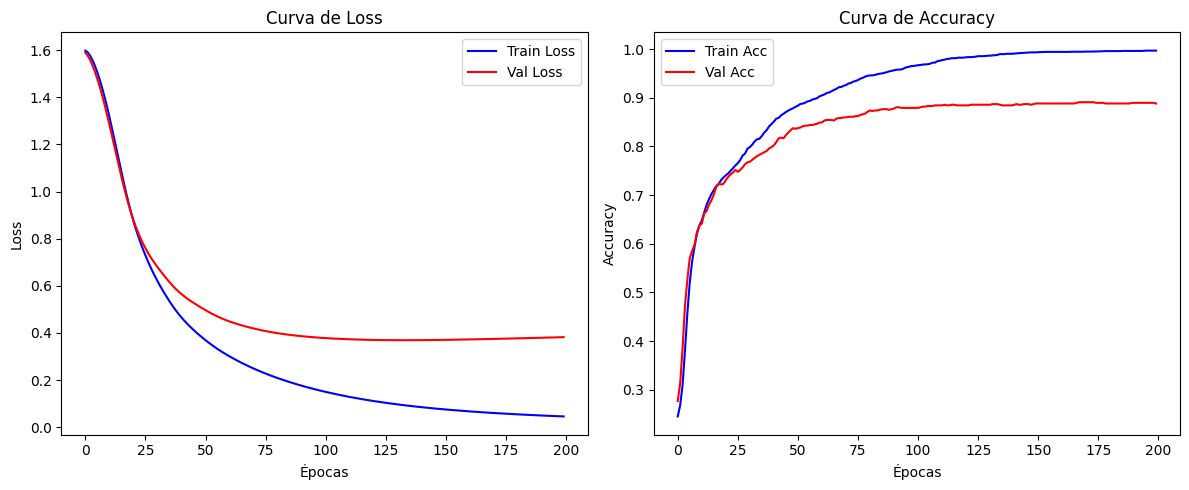


Relatório de Classificação Final:
              precision    recall  f1-score   support

   Anthropic       0.95      0.94      0.95       154
      Google       0.89      0.93      0.91       153
       Human       0.84      0.81      0.83       154
        Meta       0.91      0.88      0.89       154
      OpenAI       0.84      0.88      0.86       154

    accuracy                           0.89       769
   macro avg       0.89      0.89      0.89       769
weighted avg       0.89      0.89      0.89       769



In [6]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("A treinar o Modelo DNN Final...")

bow_final = NumpyBagOfWords(max_words=2500)
X_train_final = bow_final.fit_transform(X_train)
X_val_final = bow_final.transform(X_val)

model_final = NeuralNetwork()
model_final.add(DenseLayer(input_size=2500, output_size=164))
model_final.add(ReLUActivation())
model_final.add(DenseLayer(input_size=164, output_size=num_classes))
model_final.add(SoftmaxActivation())

model_final.compile(loss_func=CategoricalCrossEntropy(), optimizer=SGD(learning_rate=0.1))

history_final = model_final.fit(X_train_final, y_train_oh, epochs=200, val_data=(X_val_final, y_val_oh))

y_pred_final = np.argmax(model_final.forward(X_val_final, training=False), axis=1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_final['train_loss'], label='Train Loss', color='blue')
plt.plot(history_final['val_loss'], label='Val Loss', color='red')
plt.title('Curva de Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_final['train_acc'], label='Train Acc', color='blue')
plt.plot(history_final['val_acc'], label='Val Acc', color='red')
plt.title('Curva de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\nRelatório de Classificação Final:")
print(classification_report(y_val.values, y_pred_final, target_names=list(label_map.keys())))

model_final.save("../saved_models/DNN_final.pkl");
bow_final.save("../saved_models/DNN_bow_model.pkl")

In [7]:
print("Melhor Val Accuracy DNN:", max(history_final['val_acc']))
print("Melhor Val Loss DNN:", min(history_final['val_loss']))

Melhor Val Accuracy DNN: 0.8907672301690507
Melhor Val Loss DNN: 0.3691967652922898
